In [ ]:
!pip install tensorflow
!pip install emnist
!pip install gradio

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

In [ ]:
(X_train,y_train),(X_test,y_test)=tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print(X_train.shape)
print(y_train.shape)

(60000, 28, 28)
(60000,)


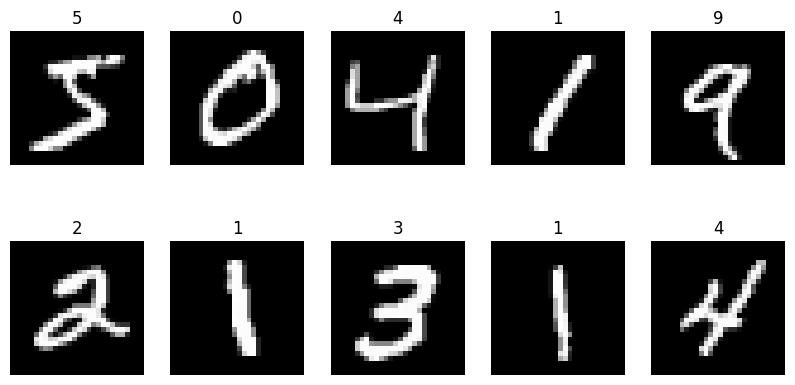

In [ ]:
plt.figure(figsize=(10,5))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(X_train[i],cmap='gray')

    plt.title(y_train[i])

    plt.axis('off')

plt.show()

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

In [ ]:
print(X_train.shape)

(60000, 28, 28, 1)


In [ ]:
model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    )
)

model.add(
    MaxPooling2D((2,2))
)

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(
    MaxPooling2D((2,2))
)

model.add(
    Flatten()
)

model.add(
    Dense(
        128,
        activation='relu'
    )
)

model.add(
    Dropout(0.3)
)

model.add(
    Dense(
        10,
        activation='softmax'
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test,y_test)
)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 52s 53ms/step - accuracy: 0.9408 - loss: 0.1935 - val_accuracy: 0.9850 - val_loss: 0.0519
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 50s 54ms/step - accuracy: 0.9810 - loss: 0.0639 - val_accuracy: 0.9874 - val_loss: 0.0400
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 83s 55ms/step - accuracy: 0.9857 - loss: 0.0458 - val_accuracy: 0.9912 - val_loss: 0.0255
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 51s 54ms/step - accuracy: 0.9885 - loss: 0.0365 - val_accuracy: 0.9903 - val_loss: 0.0298
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 51s 54ms/step - accuracy: 0.9911 - loss: 0.0288 - val_accuracy: 0.9913 - val_loss: 0.0257
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 49s 53ms/step - accuracy: 0.9921 - loss: 0.0250 - val_accuracy: 0.9912 - val_loss: 0.0258
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 84s 55ms/step - accuracy: 0.9932 - loss: 0.0205 - val_accuracy: 0.9915 - val_loss: 0.0250
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 51s 54ms/step - accuracy: 0.9940 - loss: 0.0184 - 

In [ ]:
loss,acc = model.evaluate(
    X_test,
    y_test
)

print("Accuracy:",acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9930 - loss: 0.0251
Accuracy: 0.9929999709129333


In [ ]:
prediction = model.predict(X_test[:1])

print("Predicted Digit:",
      np.argmax(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
Predicted Digit: 7


313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step


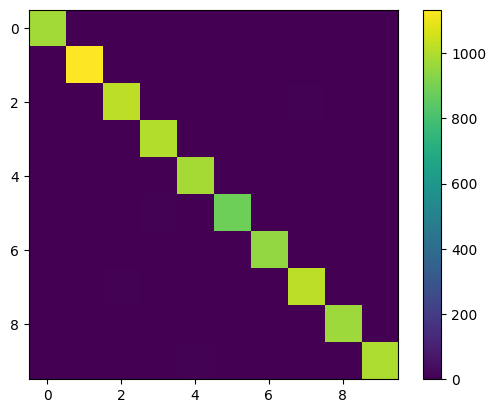

In [ ]:
from sklearn.metrics import confusion_matrix

pred = model.predict(X_test)

pred = np.argmax(pred,axis=1)

cm = confusion_matrix(
    y_test,
    pred
)

plt.imshow(cm)

plt.colorbar()

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        pred
    )
)

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       980
           1       1.00      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       1.00      0.99      1.00       974
           9       1.00      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



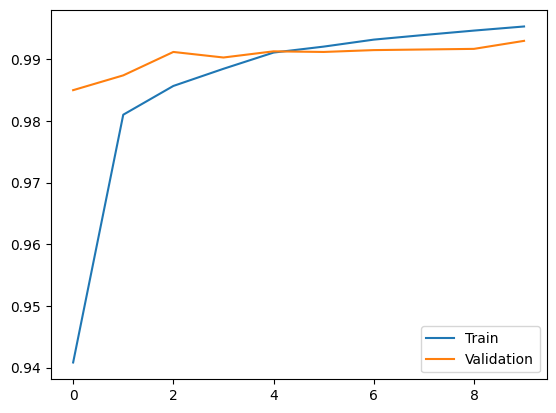

In [ ]:
plt.plot(
    history.history['accuracy']
)

plt.plot(
    history.history['val_accuracy']
)

plt.legend(
    ['Train','Validation']
)

plt.show()

In [ ]:
model.save(
    "handwritten_character_model.keras"
)